In [1]:
## libraries to install ##
#!pip install seaborn pandas matplotlib numpy tabulate plotly

import os
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt
import plotly.express as px
import numpy as np
from matplotlib.gridspec import GridSpec

from hbn.constants import Defaults  
from hbn.visualization import make_tables, visualize as vis, raw_scores
from hbn.visualization import utils as utils

import plotly.io as pio
pio.renderers.default='notebook'

%load_ext autoreload
%autoreload 2

import warnings
warnings.filterwarnings('ignore')

### Do girls with ADHD have greater risk of psychiatric comorbidity than boys?
A. What is the risk probability of comorbidities for girls and boys diagnosed with ADHD \
B. How does this vary across age? \
C. How does this risk probability change for subtypes? \
* Inattentive, Hyperactive, Combined 

What are the specific comorbidities that we see in girls compared to boys? ADHD + OD + CD + +ASD + suicidal behavior (is this especially pronounced in girls compared to boys?) 

### Main results:
* Of all comorbidities, anxiety disorders rank #1 for boys and girls with ADHD (true for all subtypes)
* Girls have a higher risk probability for comorbid anxiety than boys (true for all subtypes). difference is not as large for hyperactive type
* Girls also have a higher risk probability for reading impairment (but this is only true for inattentive type)
*  For girls and boys with ADHD, the risk probability for comorbid anxiety and depression is the same before the age of 11, but for girls increases from age 12 - 18 (slope is steeper for girls than boys) (slopes are steeper for inattentive type than combined type)


In [2]:
### FUNCTIONS ### 

def load_data():
    from hbn.constants import Defaults 
    import pandas as pd

    def _remap_dx(x):
        from hbn.visualization import utils
        dx = utils.remap_dx()

        if x in dx.keys():
            return dx[x]
        else:
            return x

    # load data
    df =  pd.read_csv(os.path.join(Defaults.INTERIM_FEATURES_DIR, 'participant_train_test.csv'))

    # remap cols
    for col in ['DX_Cat_Name', 'DX_Subtype_Name', 'DX_ADHD', 'DX_Depression', 'DX_Anxiety']:
         df[col] = df[col].apply(lambda x: _remap_dx(x))

    return df



## Load data ##

# load data
df = load_data()

# which diagnoses do we want
dx_to_include = ['Anxiety Disorders', 'Conduct Disorders',
                  'Neurodevelopmental Disorders', 'Depressive Disorders', 'Autism Spectrum Disorder',
                  'Obsessive Compulsive Disorder', 'Reading Impairment',]

## Figure 1

In [54]:
## FIGURES ## 


def calculate_comorbidities_risk(df, sex=['male', 'female'],adhd_dx=['ADHD (Combined Type)'], age_min=6, age_max=18):
    from collections import defaultdict
    import pandas as pd

    # filter dataset to only include girls and boys with ADHD
    dx_identifiers = df[df['DX_Cat_Name'].isin(adhd_dx)]['Identifiers'].unique()
    adhd_df = df[(df['Identifiers'].isin(dx_identifiers)) & (df['Age_round'].between(age_min, age_max))]

    data_dict_all = defaultdict(list)
    # what % of girls and boys are diagnosed with each `dx`?
    for dx in adhd_df['DX_Cat_Name'].fillna('N/A').unique():

        # only get non-ADHD diagnosis
        if 'ADHD' not in dx:
        
            # filter dataset for sex
            adhd_sex = adhd_df[adhd_df['Sex'].isin(sex)]

            # total count
            total_sex = len(adhd_sex['Identifiers'].unique())

            # calculate number of participants with dx
            dx_sex = len(adhd_sex[adhd_sex['DX_Cat_Name']==dx]['Identifiers'].unique())

            # calculate risk
            risk = (dx_sex / total_sex) * 100

            # update data dictionary
            data_dict = {'Sex': ''.join(sex), 'DX': dx, 'risk': risk, 'adhd_dx': '-'.join(adhd_dx)}

            for k,v in data_dict.items():
                data_dict_all[k].append(v)

    df_out = pd.DataFrame.from_dict(data_dict_all)

    return df_out

def calculate_comorbidities_risk_age(df, 
                                     sex=['male', 'female'], 
                                     adhd_dx=['ADHD (Combined Type)'], 
                                     dx='Anxiety Disorders', 
                                     age_min=6, 
                                     age_max=18):
    from collections import defaultdict
    import pandas as pd

    # filter dataset to only include girls and boys with ADHD
    dx_identifiers = df[df['DX_Cat_Name'].isin(adhd_dx)]['Identifiers'].unique()
    adhd_df = df[(df['Identifiers'].isin(dx_identifiers)) & (df['Age_round'].between(age_min, age_max))]

    data_dict_all = defaultdict(list)
    # what % of girls and boys are diagnosed with each `dx`?
    for age in adhd_df['Age_round'].unique():
        # filter dataset for sex and age
        adhd_sex_age = adhd_df[(adhd_df['Sex'].isin(sex)) & (adhd_df['Age_round']==age)]

        # total count
        total_sex_age = len(adhd_sex_age['Identifiers'].unique())

        # calculate number of participants with dx
        dx_sex = len(adhd_sex_age[adhd_sex_age['DX_Cat_Name']==dx]['Identifiers'].unique())

        # calculate risk
        if dx_sex > 0:
            risk = (dx_sex / total_sex_age) *100
        else:
            risk = 0

        # update data dictionary
        data_dict = {'Sex': ''.join(sex), 'DX': dx, 'age': round(age), 'risk': risk, 'adhd_dx': '-'.join(adhd_dx)}

        for k,v in data_dict.items():
            data_dict_all[k].append(v)

    df_out = pd.DataFrame.from_dict(data_dict_all)

    return df_out


Text(0, 0.5, 'Rate of Diagnosis across age (%)')

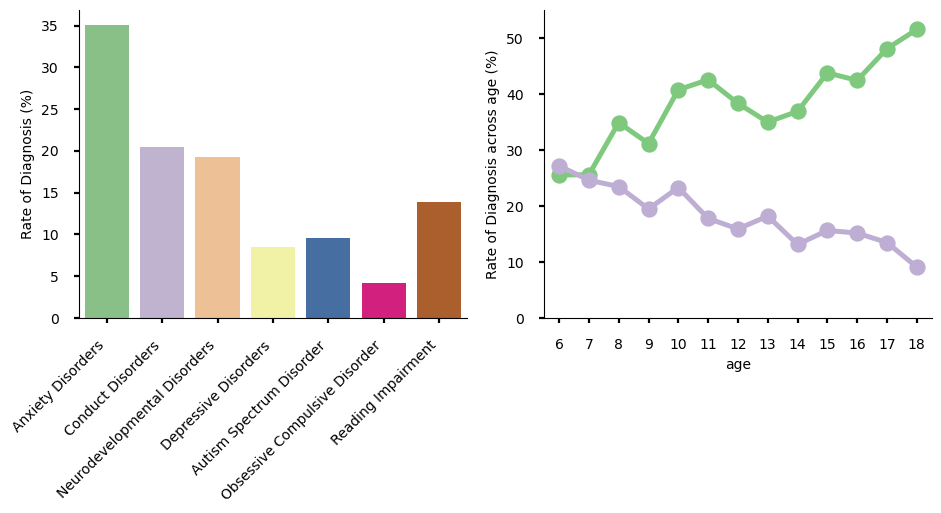

In [78]:
vis.plotting_style(palette='Accent')
fig = plt.figure(figsize=(11,4))
gs = GridSpec(1, 2, figure=fig)

# A # 
adhd_dx = ['ADHD (Combined Type)', 'ADHD (Inattentive Type)',
       'Other Specified Attention-Deficit/Hyperactivity Disorder',
       'ADHD (Hyperactive Type)']
df_risk = calculate_comorbidities_risk(df, sex=['male', 'female'], adhd_dx=adhd_dx)

ax = fig.add_subplot(gs[0, 0])
ax = sns.barplot(x='DX', y='risk', data=df_risk[df_risk['DX'].isin(dx_to_include)], order=dx_to_include, ax=ax)
plt.xticks(rotation=45, ha='right')
# ax.set_title('All ADHD Diagnoses', fontsize=10)
ax.set_xlabel('')
ax.set_ylabel('Rate of Diagnosis (%)')

# B # 
# visualize risk
dx_all = pd.DataFrame()
for dx in ['Anxiety Disorders', 'Conduct Disorders']:
       df_risk_age = calculate_comorbidities_risk_age(df, 
                                                 sex=['male', 'female'], 
                                                 adhd_dx=adhd_dx, 
                                                 dx=dx, 
                                                 age_min=6, 
                                                 age_max=18
                                                 )
       dx_all = pd.concat([dx_all, df_risk_age])

ax = fig.add_subplot(gs[0, 1])
ax = sns.pointplot(x='age', y='risk', hue='DX', data=dx_all, ax=ax,)
ax.legend().set_title('')
ax.legend().remove()
ax.set_ylim([0, 55])
ax.set_ylabel('Rate of Diagnosis across age (%)')

Text(0, 0.5, 'Rate of Diagnosis across age (%)')

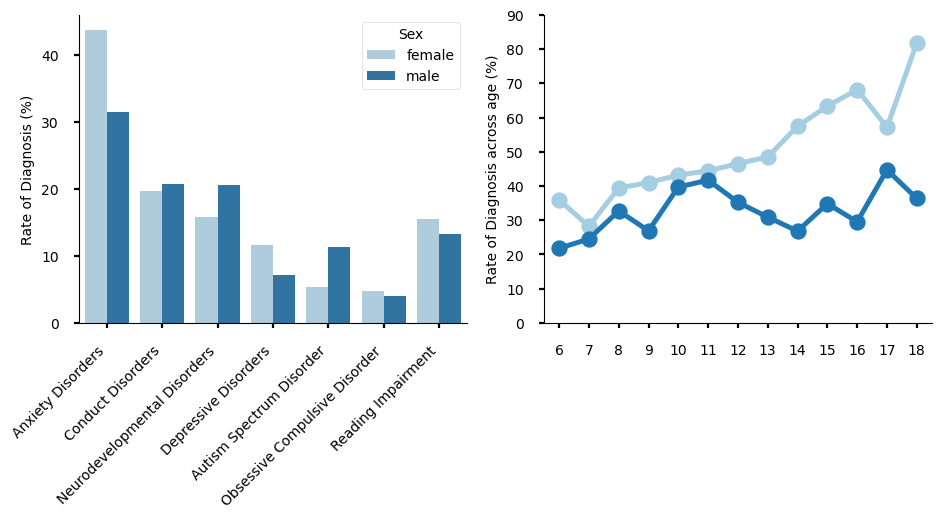

In [60]:
vis.plotting_style()
fig = plt.figure(figsize=(11,4))
gs = GridSpec(1, 2, figure=fig)

# A # 
adhd_dx = ['ADHD (Combined Type)', 'ADHD (Inattentive Type)',
       'Other Specified Attention-Deficit/Hyperactivity Disorder',
       'ADHD (Hyperactive Type)']

dx_all = pd.DataFrame()
for sex in ['male', 'female']:
       df_risk = calculate_comorbidities_risk(df, sex=[sex], adhd_dx=adhd_dx)
       dx_all = pd.concat([dx_all, df_risk])

ax = fig.add_subplot(gs[0, 0])
df1 = dx_all[dx_all['DX'].isin(dx_to_include)]
ax = sns.barplot(x='DX', y='risk', hue='Sex', data=df1.sort_values(by='Sex'), order=dx_to_include, ax=ax)
plt.xticks(rotation=45, ha='right')
# ax.set_title('All ADHD Diagnoses', fontsize=10)
ax.set_xlabel('')
ax.set_ylabel('Rate of Diagnosis (%)')

# B # 
# visualize risk
dx_all = pd.DataFrame()
for sex in ['male', 'female']:
       df_risk_age = calculate_comorbidities_risk_age(df, 
                                                 sex=[sex], 
                                                 adhd_dx=adhd_dx, 
                                                 dx='Anxiety Disorders', 
                                                 age_min=6, 
                                                 age_max=18
                                                 )
       dx_all = pd.concat([dx_all, df_risk_age])

ax = fig.add_subplot(gs[0, 1])
ax = sns.pointplot(x='age', y='risk', hue='Sex', data=dx_all.sort_values(by='Sex'), ax=ax)
ax.legend().set_title('')
ax.legend().remove()
ax.set_ylim([0, 90])
ax.set_xlabel('')
ax.set_ylabel('Rate of Diagnosis across age (%)')

## Supplemental Figure 1

Text(0.5, 1.0, 'ADHD (Hyperactive/Impulsive)')

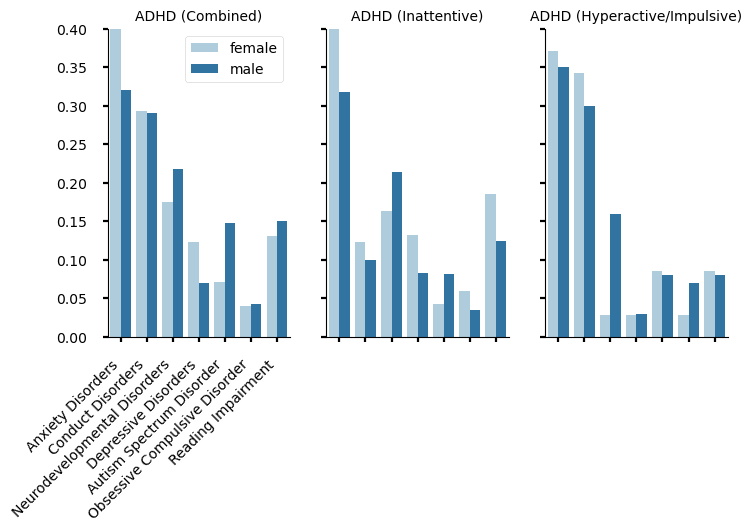

In [47]:

# which diagnoses do we want
dx_to_include = ['Anxiety Disorders', 'Conduct Disorders',
                  'Neurodevelopmental Disorders', 'Depressive Disorders', 'Autism Spectrum Disorder',
                  'Obsessive Compulsive Disorder', 'Reading Impairment',]

vis.plotting_style()
fig = plt.figure(figsize=(8,4))
gs = GridSpec(1, 3, figure=fig)

# visualize risk
df_risk = calculate_comorbidities_risk(df, adhd_dx=['ADHD (Combined Type)'])

ax = fig.add_subplot(gs[0, 0])
ax = sns.barplot(x='DX', y='risk', hue='Sex', data=df_risk[df_risk['DX'].isin(dx_to_include)].sort_values(by='Sex'), order=dx_to_include, ax=ax)
plt.xticks(rotation=45, ha='right')
ax.set_title('ADHD (Combined)', fontsize=10)
# ax.legend().remove()
ax.legend().set_title('')
ax.set_xlabel('')
ax.set_ylim(0,.4)
ax.set_ylabel('')

# visualize risk
df_risk = calculate_comorbidities_risk(df, adhd_dx=['ADHD (Inattentive Type)'])

ax = fig.add_subplot(gs[0, 1])
ax = sns.barplot(x='DX', y='risk', hue='Sex', data=df_risk[df_risk['DX'].isin(dx_to_include)].sort_values(by='Sex'),order=dx_to_include, ax=ax)
plt.xticks(rotation=45, ha='right')
ax.legend().remove()
ax.set_title('ADHD (Inattentive)', fontsize=10)
ax.set_xlabel('')
ax.set_ylabel('')
ax.set_yticklabels('')
ax.set_xticklabels('')
ax.set_ylim(0,.4)

# visualize risk
df_risk = calculate_comorbidities_risk(df, adhd_dx=['ADHD (Hyperactive Type)'])

ax = fig.add_subplot(gs[0, 2])
ax = sns.barplot(x='DX', y='risk', hue='Sex', data=df_risk[df_risk['DX'].isin(dx_to_include)].sort_values(by='Sex'), order=dx_to_include,ax=ax)
plt.xticks(rotation=45, ha='right')
ax.legend().remove()
ax.set_xlabel('')
ax.set_ylabel('')
ax.set_yticklabels('')
ax.set_xticklabels('')
ax.set_ylim(0,.4)
ax.set_title('ADHD (Hyperactive/Impulsive)', fontsize=10)

### Figure 2

In [3]:

def calculate_perc_comorbidities(x):
    from collections import defaultdict

    data_dict = defaultdict(list)
    for comorbid in x['comorbidities'].unique():

        total_participants = len(x['Identifiers'].unique())
        count = len(x[x['comorbidities']==comorbid]['Identifiers'].unique())
        perc = count / total_participants

        data = {'comorbidity': comorbid, 'total_participants': total_participants, 'count': count, 'perc': round(perc*100, 2)}

        for k,v in data.items():
            data_dict[k].append(v)

    return pd.DataFrame.from_dict(data_dict)


def calculate_perc_overall(x):
    from collections import defaultdict

    data_dict = defaultdict(list)
    total_participants = len(x['Identifiers'].unique())
    count = len(x[x['comorbidities']>0]['Identifiers'].unique())
    perc = count / total_participants

    data = {'comorbidities': x['comorbidities'].mean(),'total_participants': total_participants, 'count': count, 'perc': round(perc*100, 2)}

    for k,v in data.items():
        data_dict[k].append(v)

    return pd.DataFrame.from_dict(data_dict)


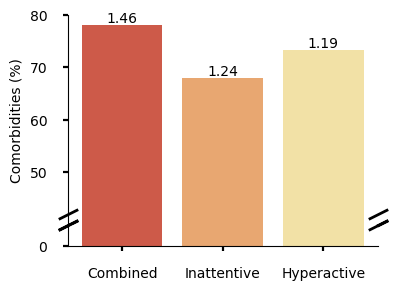

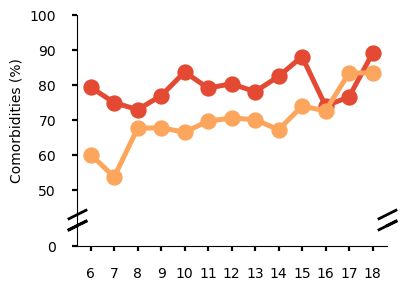

In [19]:

# A
vis.plotting_style(palette='RdYlGn')
fig, (ax1, ax2) = plt.subplots(2, 1,
                            sharex=True,
                            gridspec_kw={
                            'height_ratios': [1, 0.1]
                            })
fig.subplots_adjust(hspace=0.0)
fig.set_size_inches(4, 3)

adhd_dx = ['ADHD (Combined Type)', 'ADHD (Inattentive Type)','ADHD (Hyperactive Type)']

df_subtypes_perc_overall = df[(df['DX_Subtype_Name'] \
                               .isin(adhd_dx)) \
                                & (df['Age_round'].between(6, 18))] \
                                    .groupby([ 'DX_Subtype_Name']) \
                                        .apply(lambda x: calculate_perc_overall(x)).reset_index()

# barplot (left hand y axis)
xticklabels = ['Combined', 'Inattentive', 'Hyperactive']
ax1 = vis.barplot(x='DX_Subtype_Name', y='perc', xticklabels=xticklabels, ylim=None, ylabel='Comorbidities (%)', order=adhd_dx, data=df_subtypes_perc_overall, ax=ax1)
ax2 = vis.barplot(x='DX_Subtype_Name', y='perc',  xticklabels=xticklabels, ylim=None, legend=False, ylabel='', order=adhd_dx, data=df_subtypes_perc_overall, ax=ax2)

ax1, ax2 = vis.modify_axes(ax1, ax2)
vis._draw_cut(ax1, ax2)

## add labels to bars ##
df_mean = df[(df['DX_Subtype_Name'].isin(adhd_dx)) \
                 & (df['Age_round'].between(6, 18))] \
                 .groupby('DX_Subtype_Name')['comorbidities'].mean().reset_index(name='mean')

for p, val in zip(ax1.patches, df_mean.index):
    height = p.get_height()
    label = round(df_mean.loc[val, 'mean'], 2).astype(str)
    x = p.get_x() + p.get_width() / 2
    y = height
    ax1.annotate(label, (x, y), ha='center', va='bottom')

# B
fig, (ax1, ax2) = plt.subplots(2, 1,
                            sharex=True,
                            gridspec_kw={
                            'height_ratios': [1, 0.1]
                            })
fig.subplots_adjust(hspace=0.0)
fig.set_size_inches(4, 3)

# get perc overall
df_subtypes_perc_age = df[(df['DX_Subtype_Name'] \
                               .isin(['ADHD (Combined Type)', 'ADHD (Inattentive Type)'])) \
                                & (df['Age_round'].between(6, 18))] \
                                    .groupby([ 'DX_Subtype_Name', 'Age_round']) \
                                        .apply(lambda x: calculate_perc_overall(x)).reset_index()
df_subtypes_perc_age['Age_round'] = df_subtypes_perc_age['Age_round'].astype(int)

# pointplot (left hand y axis)
ax1 = vis.pointplot(x='Age_round', y='perc', ylim=None, hue='DX_Subtype_Name',  legend=False, ylabel='Comorbidities (%)', data=df_subtypes_perc_age, ax=ax1)
ax2 = vis.pointplot(x='Age_round', y='perc',  ylim=None, hue='DX_Subtype_Name', legend=False, ylabel='', data=df_subtypes_perc_age, ax=ax2)

ax1, ax2 = vis.modify_axes(ax1, ax2, ylim_outliers=(40, 95), ylim_data=(0, 10))
_draw_cut(ax1, ax2)

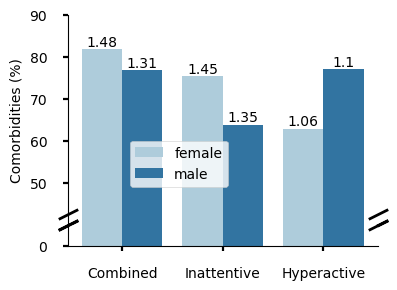

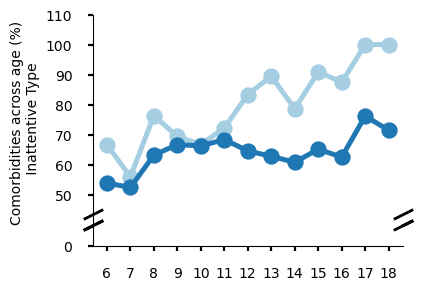

In [102]:
# A
vis.plotting_style(palette='Paired')
fig, (ax1, ax2) = plt.subplots(2, 1,
                            sharex=True,
                            gridspec_kw={
                            'height_ratios': [1, 0.1]
                            })
fig.subplots_adjust(hspace=0.0)
fig.set_size_inches(4, 3)

adhd_dx = ['ADHD (Combined Type)', 'ADHD (Inattentive Type)','ADHD (Hyperactive Type)']

df_subtypes_perc_overall = df[(df['DX_Subtype_Name'] \
                               .isin(adhd_dx)) \
                                & (df['Age_round'].between(6, 18))] \
                                    .groupby(['DX_Subtype_Name', 'Sex']) \
                                        .apply(lambda x: calculate_perc_overall(x)).reset_index()

# barplot (left hand y axis)
xticklabels = ['Combined', 'Inattentive', 'Hyperactive']
ax1 = vis.barplot(x='DX_Subtype_Name', y='perc', hue='Sex', xticklabels=xticklabels, ylim=None, ylabel='Comorbidities (%)', order=adhd_dx, data=df_subtypes_perc_overall, ax=ax1)
ax2 = vis.barplot(x='DX_Subtype_Name', y='perc',  hue='Sex', xticklabels=xticklabels, ylim=None, legend=False, ylabel='', order=adhd_dx, data=df_subtypes_perc_overall, ax=ax2)

ax1, ax2 = vis.modify_axes(ax1, ax2, ylim_outliers=(40, 90))
vis._draw_cut(ax1, ax2)

## add labels to bars ##
df_mean = df[(df['DX_Subtype_Name'].isin(adhd_dx)) \
                 & (df['Age_round'].between(6, 18))] \
                 .groupby(['DX_Subtype_Name', 'Sex'])['comorbidities'].mean().reset_index(name='mean')

for p, val in zip(ax1.patches, df_mean.index):
    height = p.get_height()
    label = round(df_mean.loc[val, 'mean'], 2).astype(str)
    x = p.get_x() + p.get_width() / 2
    y = height
    ax1.annotate(label, (x, y), ha='center', va='bottom')


# B
fig, (ax1, ax2) = plt.subplots(2, 1,
                            sharex=True,
                            gridspec_kw={
                            'height_ratios': [1, 0.1]
                            })
fig.subplots_adjust(hspace=0.0)
fig.set_size_inches(4, 3)

# get perc overall
df_subtypes_perc_age = df[(df['DX_Subtype_Name'] \
                               .isin(['ADHD (Inattentive Type)'])) \
                                & (df['Age_round'].between(6, 18))] \
                                    .groupby([ 'DX_Subtype_Name', 'Age_round', 'Sex']) \
                                        .apply(lambda x: calculate_perc_overall(x)).reset_index()
df_subtypes_perc_age['Age_round'] = df_subtypes_perc_age['Age_round'].astype(int)

# pointplot (left hand y axis)
ax1 = vis.pointplot(x='Age_round', y='perc', ylim=None, hue='Sex',  legend=False, ylabel='Comorbidities across age (%) \n Inattentive Type', data=df_subtypes_perc_age, ax=ax1)
ax2 = vis.pointplot(x='Age_round', y='perc',  ylim=None, hue='Sex', legend=False, ylabel='', data=df_subtypes_perc_age, ax=ax2)

ax1, ax2 = vis.modify_axes(ax1, ax2, ylim_outliers=(40, 100.05), ylim_data=(0, 10))
vis._draw_cut(ax1, ax2)


In [68]:

def compare_slopes(df1, df2, alpha=0.05, x='age', y='risk'):
    """
    Compares the slopes of two lines and determines if the difference is statistically significant.

    Args:
        df1, df2: Pandas DataFrames with 'x' and 'y' columns.
        alpha: Significance level for the t-test.
        x, y: Column names for the x and y variables.

    Returns:
        A tuple containing:
            - The steeper line (either 'df1' or 'df2')
            - A boolean indicating whether the difference is statistically significant
    """
    import pandas as pd
    from scipy.stats import linregress, ttest_ind
    import statsmodels.formula.api as smf

    # Calculate slopes using linear regression
    slope1 = linregress(df1[x], df1[y]).slope
    slope2 = linregress(df2[x], df2[y]).slope

    print(f'Slopes: {slope1:.3f} vs. {slope2:.3f}')
    # print(f'F statistic: {f_stat:.3f}, p-value: {p_value:.3f}')

def calculate_slopes(
    df,
    ax=None, 
    dx='DX_Cat_Name', 
    dx_vals=['ADHD'],
    ylabel='slope',
    xlabel='Age',
    ):

    df1 = df[(df[dx].isin(dx_vals)) & (df['Sex']=='female')]
    df2 = df[(df[dx].isin(dx_vals)) & (df['Sex']=='male')]
    ax = sns.regplot(x='Age_round', y='slope', data=df1, scatter_kws={'alpha': 0.5}, ax=ax)
    ax = sns.regplot(x='Age_round', y='slope', data=df2, scatter_kws={'alpha': 0.5}, ax=ax)
    plt.xticks(rotation=45, ha='right'); 
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)

    compare_slopes(df1, df2, alpha=0.05, x='Age_round', y='slope')

## Supplemental Figure 2

<Axes: >

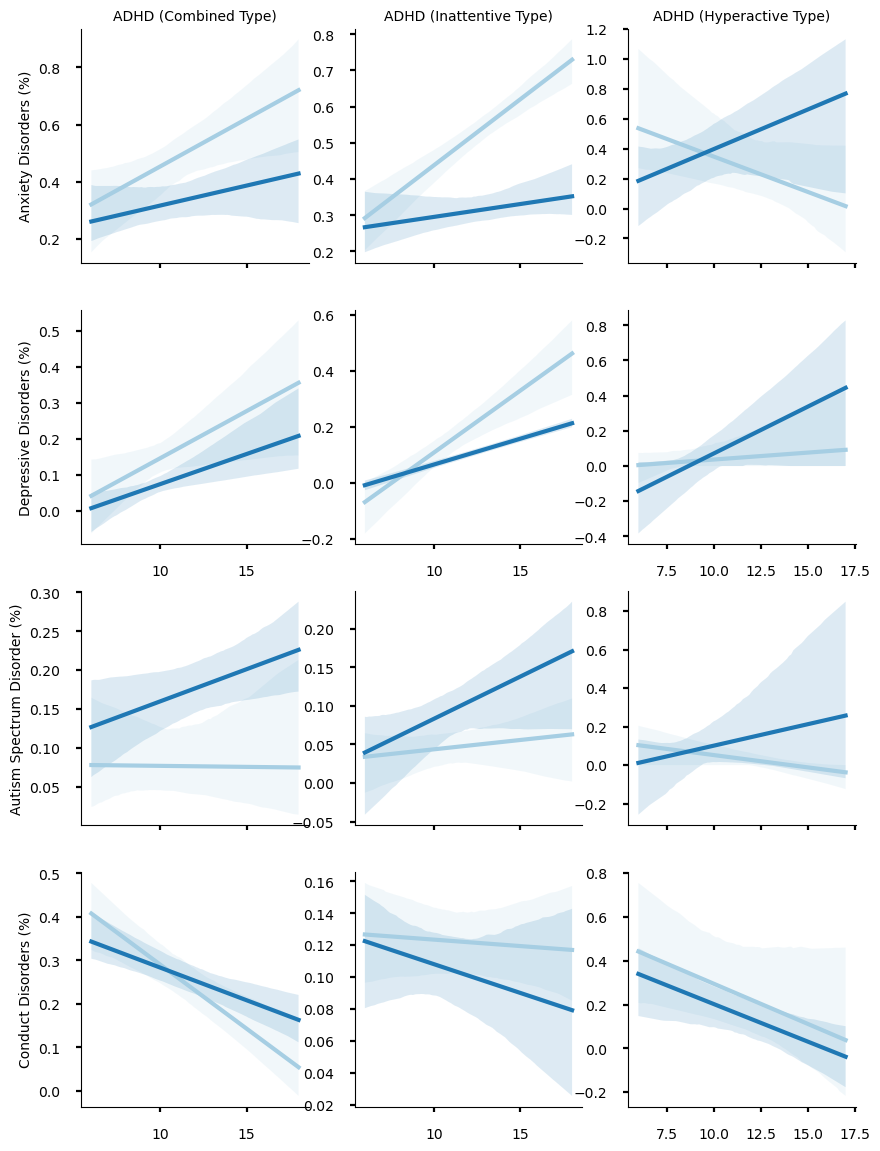

In [65]:

vis.plotting_style()
fig = plt.figure(figsize=(10,14))
gs = GridSpec(4, 3, figure=fig)

def _plot(df, ax, dx='Anxiety Disorders', xlabel='', ylabel='', xticklabels=True, yticklabels=True, title=''):
    for sex in ['female', 'male']:
        ax = sns.regplot(x='age', y='risk', 
                        data=df[df['Sex']==sex], 
                        scatter=False,
                        truncate=True,
                        label=sex,
                        ax=ax) # ci=None,scatter_kws={'alpha': 0.5},
    ax.set_ylabel(ylabel)
    ax.set_xlabel(xlabel)
    if not xticklabels:
        ax.set_xticklabels('')
    if not yticklabels:
        ax.set_yticklabels('')
    ax.set_title(title, fontsize=10)
    return ax

# A # 
dx = 'Anxiety Disorders'
df_risk_age = calculate_comorbidities_risk_age(df, adhd_dx=['ADHD (Combined Type)'], dx=dx, age_min=6, age_max=18)
ax = fig.add_subplot(gs[0, 0])
_plot(df=df_risk_age, dx=dx, xlabel='', ylabel=f'{dx} (%)',xticklabels=False, yticklabels=True, title='ADHD (Combined Type)', ax=ax)

# B # 
df_risk_age = calculate_comorbidities_risk_age(df, adhd_dx=['ADHD (Inattentive Type)'], dx=dx, age_min=6, age_max=18)
ax = fig.add_subplot(gs[0, 1])
_plot(df=df_risk_age, dx=dx, xlabel='', xticklabels=False, yticklabels=True, title='ADHD (Inattentive Type)', ax=ax)

# C # 
df_risk_age = calculate_comorbidities_risk_age(df, adhd_dx=['ADHD (Hyperactive Type)'], dx=dx, age_min=6, age_max=18)
ax = fig.add_subplot(gs[0, 2])
_plot(df=df_risk_age, dx=dx, xlabel='', xticklabels=False, yticklabels=True, title='ADHD (Hyperactive Type)', ax=ax)

# D # 
dx = 'Depressive Disorders'
df_risk_age = calculate_comorbidities_risk_age(df, adhd_dx=['ADHD (Combined Type)'], dx=dx, age_min=6, age_max=18)
ax = fig.add_subplot(gs[1, 0])
_plot(df=df_risk_age, dx=dx,  xlabel='', ylabel=f'{dx} (%)', xticklabels=True, yticklabels=True, title='', ax=ax)

# E # 
df_risk_age = calculate_comorbidities_risk_age(df, adhd_dx=['ADHD (Inattentive Type)'], dx=dx, age_min=6, age_max=18)
ax = fig.add_subplot(gs[1, 1])
_plot(df=df_risk_age, dx=dx, xticklabels=True, yticklabels=True, title='', ax=ax)

# F # 
df_risk_age = calculate_comorbidities_risk_age(df, adhd_dx=['ADHD (Hyperactive Type)'], dx=dx, age_min=6, age_max=18)
ax = fig.add_subplot(gs[1, 2])
_plot(df=df_risk_age,  dx=dx, xticklabels=True, yticklabels=True, title='', ax=ax)

# G # 
dx='Autism Spectrum Disorder'
df_risk_age = calculate_comorbidities_risk_age(df, adhd_dx=['ADHD (Combined Type)'], dx=dx, age_min=6, age_max=18)
ax = fig.add_subplot(gs[2, 0])
_plot(df=df_risk_age, dx=dx, xlabel='', ylabel=f'{dx} (%)',xticklabels=False, yticklabels=True, title='', ax=ax)

# H # 
df_risk_age = calculate_comorbidities_risk_age(df, adhd_dx=['ADHD (Inattentive Type)'], dx=dx, age_min=6, age_max=18)
ax = fig.add_subplot(gs[2, 1])
_plot(df=df_risk_age, dx=dx, xlabel='', xticklabels=False, yticklabels=True, title='', ax=ax)

# I # 
df_risk_age = calculate_comorbidities_risk_age(df, adhd_dx=['ADHD (Hyperactive Type)'], dx=dx, age_min=6, age_max=18)
ax = fig.add_subplot(gs[2, 2])
_plot(df=df_risk_age, dx=dx, xlabel='', xticklabels=False, yticklabels=True, title='', ax=ax)

# J # 
dx = 'Conduct Disorders'
df_risk_age = calculate_comorbidities_risk_age(df, adhd_dx=['ADHD (Combined Type)'], dx=dx, age_min=6, age_max=18)
ax = fig.add_subplot(gs[3, 0])
_plot(df=df_risk_age, dx=dx,  xlabel='', ylabel=f'{dx} (%)', xticklabels=True, yticklabels=True, title='', ax=ax)

# K # 
df_risk_age = calculate_comorbidities_risk_age(df, adhd_dx=['ADHD (Inattentive Type)'], dx=dx, age_min=6, age_max=18)
ax = fig.add_subplot(gs[3, 1])
_plot(df=df_risk_age, dx=dx, xticklabels=True, yticklabels=True, title='', ax=ax)

# L # 
df_risk_age = calculate_comorbidities_risk_age(df, adhd_dx=['ADHD (Hyperactive Type)'], dx=dx, age_min=6, age_max=18)
ax = fig.add_subplot(gs[3, 2])
_plot(df=df_risk_age,  dx = dx, xticklabels=True, yticklabels=True, title='', ax=ax)


